# 🏢 Parcl Real Estate — ML Buyer Segmentation & Investment Profiling



## ⚙️ Cell 1 — Install Extra Libraries

In [ ]:
!pip install -q plotly kaleido
print("✅ Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.4 MB/s eta 0:00:00
✅ Done


## 📦 Cell 2 — Import All Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11
})
PALETTE = ["#2563eb", "#16a34a", "#dc2626", "#d97706", "#7c3aed", "#0891b2"]
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 📁 Cell 3 — Upload & Load Data


In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

clients    = pd.read_csv('/content/drive/MyDrive/Parcl_Project/clients.csv')
properties = pd.read_csv('/content/drive/MyDrive/Parcl_Project/properties.csv')

print(f"✅ clients.csv    → {clients.shape[0]:,} rows × {clients.shape[1]} columns")
print(f"✅ properties.csv → {properties.shape[0]:,} rows × {properties.shape[1]} columns")
print()
print("── Clients preview ──")
display(clients.head(3))
print("── Properties preview ──")
display(properties.head(3))

Mounted at /content/drive
✅ clients.csv    → 2,000 rows × 12 columns
✅ properties.csv → 10,000 rows × 9 columns

── Clients preview ──


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency


── Properties preview ──


,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113


## 🔍 Cell 4 — Data Overview & Missing Values

In [ ]:
print("=" * 55)
print("CLIENTS — Basic Info")
print("=" * 55)
print(clients.dtypes)
print()
print("Missing values:")
print(clients.isnull().sum())
print()
print("── Column unique value counts ──")
for col in clients.columns:
    print(f"  {col:25s}: {clients[col].nunique()} unique")

print()
print("=" * 55)
print("PROPERTIES — Basic Info")
print("=" * 55)
print(properties.dtypes)
print()
print("Missing values:")
print(properties.isnull().sum())

CLIENTS — Basic Info
client_id              object
client_type            object
first_name             object
last_name              object
date_of_birth          object
gender                 object
country                object
region                 object
acquisition_purpose    object
satisfaction_score      int64
loan_applied           object
referral_channel       object
dtype: object

Missing values:
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

── Column unique value counts ──
  client_id                : 2000 unique
  client_type              : 2 unique
  first_name               : 337 unique
  last_name                : 224 unique
  date_of_birth            : 1889 unique
  gender                   : 2 unique
  c

## 🧹 Cell 5 — Data Cleaning

In [ ]:
print("=" * 55)
print("STEP 1: DATA CLEANING")
print("=" * 55)

# ── CLIENTS ──────────────────────────────────────────────────────────────────
# Remove duplicates
before = len(clients)
clients.drop_duplicates(inplace=True)
print(f"Duplicate rows removed (clients): {before - len(clients)}")

# Parse date_of_birth (two formats exist: MM-DD-YYYY and MM/DD/YYYY)
clients["date_of_birth"] = pd.to_datetime(
    clients["date_of_birth"], format='mixed', dayfirst=False
)
ref_date = pd.Timestamp("2024-01-01")
clients["age"] = ((ref_date - clients["date_of_birth"]).dt.days / 365.25).astype(int)

# Standardise text columns
for col in ["client_type", "gender", "country", "region",
            "acquisition_purpose", "loan_applied", "referral_channel"]:
    clients[col] = clients[col].str.strip().str.title()

print(f"Age range: {clients['age'].min()} – {clients['age'].max()} years")

# ── PROPERTIES ───────────────────────────────────────────────────────────────
before = len(properties)
properties.drop_duplicates(inplace=True)
print(f"Duplicate rows removed (properties): {before - len(properties)}")

# Clean sale_price: remove $ and commas → float
properties["sale_price"] = (
    properties["sale_price"]
    .str.replace(r"[$,]", "", regex=True)
    .astype(float)
)

# Parse transaction_date
properties["transaction_date"] = pd.to_datetime(
    properties["transaction_date"], infer_datetime_format=True
)

for col in ["unit_category", "listing_status"]:
    properties[col] = properties[col].str.strip().str.title()

# Keep only Sold listings with a known client_ref
sold = properties[
    (properties["listing_status"] == "Sold") &
    (properties["client_ref"].notna())
].copy()

print(f"\nSold listings with client reference: {len(sold):,}")
print()
print("✅ Clients cleaned")
print("✅ Properties cleaned")

STEP 1: DATA CLEANING
Duplicate rows removed (clients): 0
Age range: 23 – 92 years
Duplicate rows removed (properties): 0

Sold listings with client reference: 7,305

✅ Clients cleaned
✅ Properties cleaned


## 🔗 Cell 6 — Merge Datasets

In [ ]:
# Aggregate property transactions per client
agg = (
    sold.groupby("client_ref")
    .agg(
        total_spend   = ("sale_price",      "sum"),
        units_bought  = ("listing_id",      "count"),
        avg_area_sqft = ("floor_area_sqft", "mean"),
        max_price     = ("sale_price",      "max"),
        has_office    = ("unit_category",   lambda x: int((x == "Office").any()))
    )
    .reset_index()
    .rename(columns={"client_ref": "client_id"})
)

# Merge with client data
df = clients.merge(agg, on="client_id", how="left")

# Fill NaN for clients with no transactions
fill_cols = ["total_spend", "units_bought", "avg_area_sqft", "max_price", "has_office"]
df[fill_cols] = df[fill_cols].fillna(0)

print(f"✅ Merged dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Clients with property transactions: {(df['units_bought'] > 0).sum():,}")
print()
display(df.head())

✅ Merged dataset: 2,000 rows × 18 columns
   Clients with property transactions: 2,000



,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,total_spend,units_bought,avg_area_sqft,max_price,has_office
0,C0001,Individual,Kareem,Liu,1968-05-11,F,Usa,California,Home,4,Yes,Website,55,1246764.72,4,983.885000,496266.41,0
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,Usa,California,Home,1,No,Website,61,1841095.93,5,1187.942000,505127.63,0
2,C0003,Individual,Kale,Gay,1959-04-07,M,Usa,California,Home,4,Yes,Agency,64,1661457.59,5,1058.110000,584611.99,0
3,C0004,Individual,Russell,Gross,1959-11-25,M,Usa,California,Home,5,No,Website,64,1608263.51,6,937.103333,606634.75,0
4,C0005,Company,Marleez,Co,1976-02-28,M,Usa,California,Investment,5,No,Website,47,3653385.38,13,927.296154,628812.33,0


## 📊 Cell 7 — EDA: Distribution Plots

STEP 2: EXPLORATORY DATA ANALYSIS

── Numeric Summary ──


,age,satisfaction_score,total_spend,units_bought,avg_area_sqft
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,53.10,3.03,1260375.48,3.65,1147.48
std,17.34,1.41,347830.66,0.84,219.92
min,23.00,1.00,463611.95,3.00,564.01
25%,38.00,2.00,1025238.00,3.00,984.95
50%,54.00,3.00,1220893.16,4.00,1129.18
75%,68.00,4.00,1441973.88,4.00,1296.56
max,92.00,5.00,3653385.38,13.00,1800.45


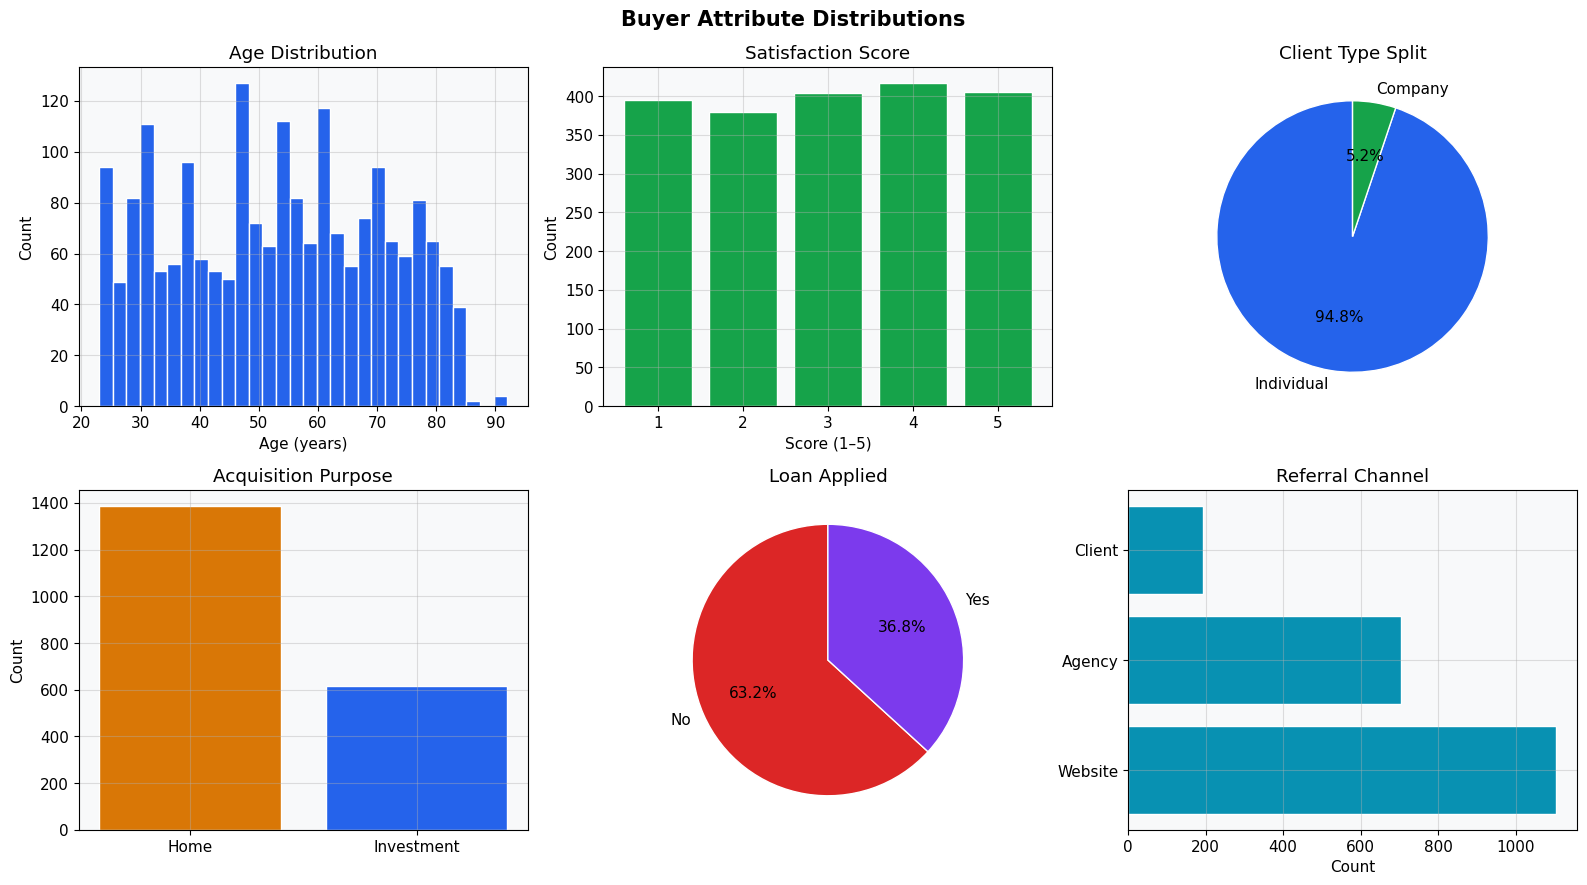

✅ Saved: eda_distributions.png


In [ ]:
print("=" * 55)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("=" * 55)
print()
print("── Numeric Summary ──")
display(df[["age", "satisfaction_score", "total_spend", "units_bought", "avg_area_sqft"]].describe().round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Buyer Attribute Distributions", fontsize=15, fontweight="bold")

# Age
axes[0,0].hist(df["age"], bins=30, color=PALETTE[0], edgecolor="white")
axes[0,0].set_title("Age Distribution")
axes[0,0].set_xlabel("Age (years)")
axes[0,0].set_ylabel("Count")

# Satisfaction score
sc = df["satisfaction_score"].value_counts().sort_index()
axes[0,1].bar(sc.index, sc.values, color=PALETTE[1], edgecolor="white")
axes[0,1].set_title("Satisfaction Score")
axes[0,1].set_xlabel("Score (1–5)")
axes[0,1].set_ylabel("Count")

# Client type
ct = df["client_type"].value_counts()
axes[0,2].pie(ct, labels=ct.index, autopct="%1.1f%%",
              colors=PALETTE[:2], startangle=90,
              wedgeprops=dict(edgecolor="white"))
axes[0,2].set_title("Client Type Split")

# Acquisition purpose
ap = df["acquisition_purpose"].value_counts()
axes[1,0].bar(ap.index, ap.values, color=[PALETTE[3], PALETTE[0]], edgecolor="white")
axes[1,0].set_title("Acquisition Purpose")
axes[1,0].set_ylabel("Count")

# Loan applied
la = df["loan_applied"].value_counts()
axes[1,1].pie(la, labels=la.index, autopct="%1.1f%%",
              colors=[PALETTE[2], PALETTE[4]],
              startangle=90, wedgeprops=dict(edgecolor="white"))
axes[1,1].set_title("Loan Applied")

# Referral channel
rc = df["referral_channel"].value_counts()
axes[1,2].barh(rc.index, rc.values, color=PALETTE[5], edgecolor="white")
axes[1,2].set_title("Referral Channel")
axes[1,2].set_xlabel("Count")

plt.tight_layout()
plt.savefig("eda_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_distributions.png")

## 🌍 Cell 8 — EDA: Geography & Investment Analysis

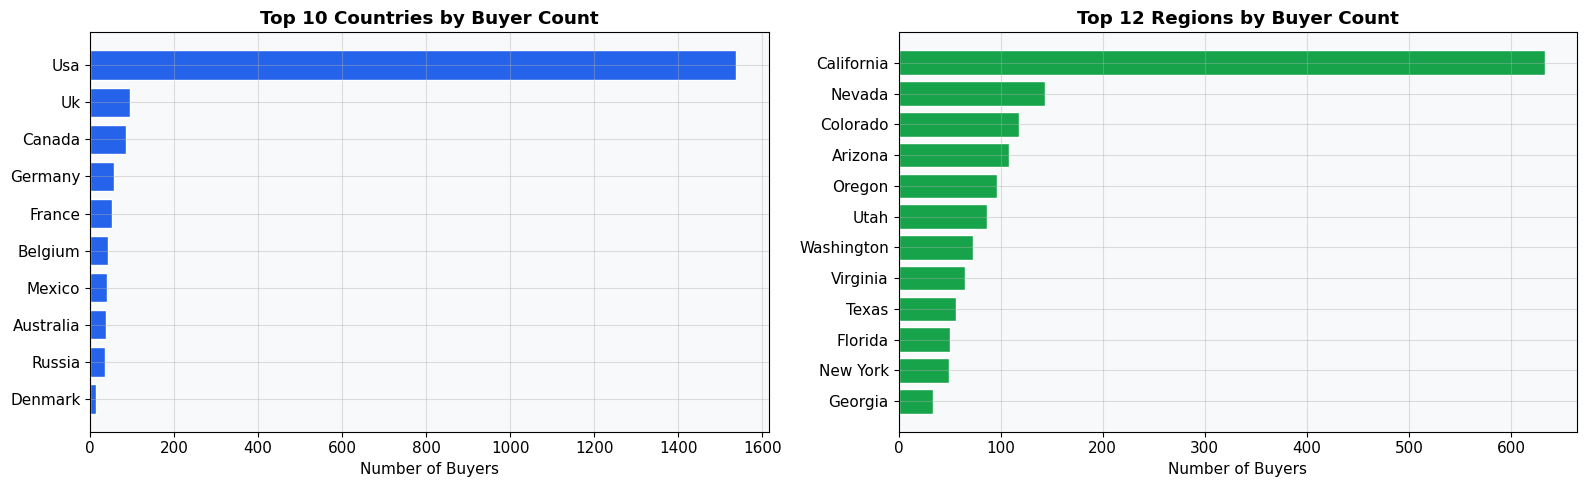

✅ Saved: eda_geography.png


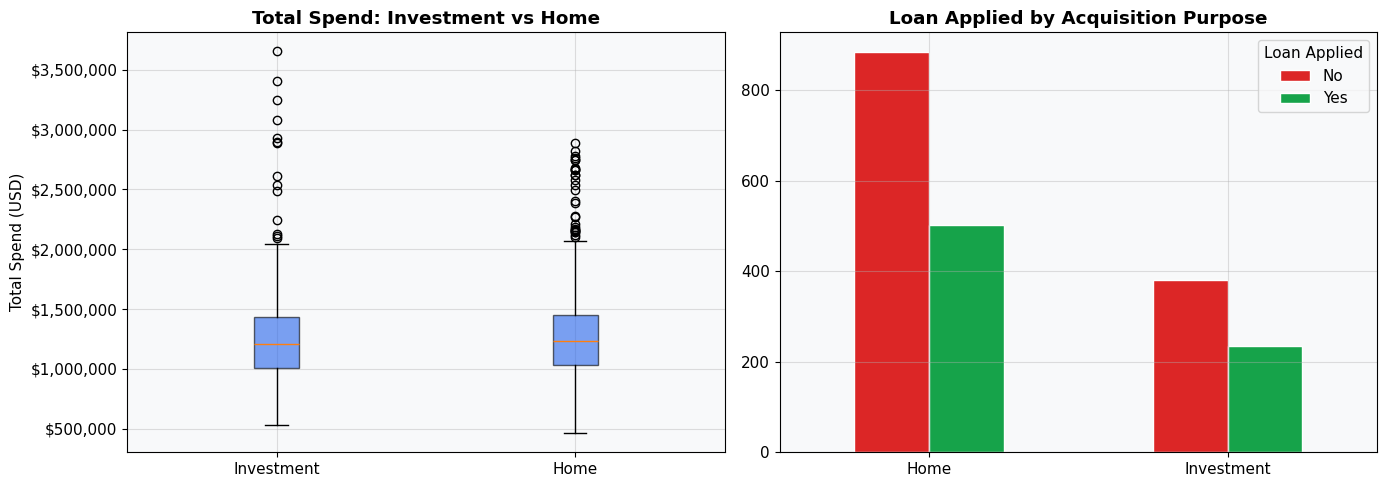

✅ Saved: eda_investment.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_countries = df["country"].value_counts().head(10)
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1],
             color=PALETTE[0], edgecolor="white")
axes[0].set_title("Top 10 Countries by Buyer Count", fontweight="bold")
axes[0].set_xlabel("Number of Buyers")

top_regions = df["region"].value_counts().head(12)
axes[1].barh(top_regions.index[::-1], top_regions.values[::-1],
             color=PALETTE[1], edgecolor="white")
axes[1].set_title("Top 12 Regions by Buyer Count", fontweight="bold")
axes[1].set_xlabel("Number of Buyers")

plt.tight_layout()
plt.savefig("eda_geography.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_geography.png")

# Investment vs Home — spend and loan analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

buyers_only = df[df["total_spend"] > 0]
data_inv  = buyers_only[buyers_only["acquisition_purpose"] == "Investment"]["total_spend"]
data_home = buyers_only[buyers_only["acquisition_purpose"] == "Home"]["total_spend"]
axes[0].boxplot([data_inv, data_home], labels=["Investment", "Home"],
                patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.6))
axes[0].set_title("Total Spend: Investment vs Home", fontweight="bold")
axes[0].set_ylabel("Total Spend (USD)")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ct_pivot = pd.crosstab(df["acquisition_purpose"], df["loan_applied"])
ct_pivot.plot(kind="bar", ax=axes[1],
              color=[PALETTE[2], PALETTE[1]], edgecolor="white")
axes[1].set_title("Loan Applied by Acquisition Purpose", fontweight="bold")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Loan Applied")

plt.tight_layout()
plt.savefig("eda_investment.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_investment.png")

## 🔥 Cell 9 — EDA: Correlation Heatmap

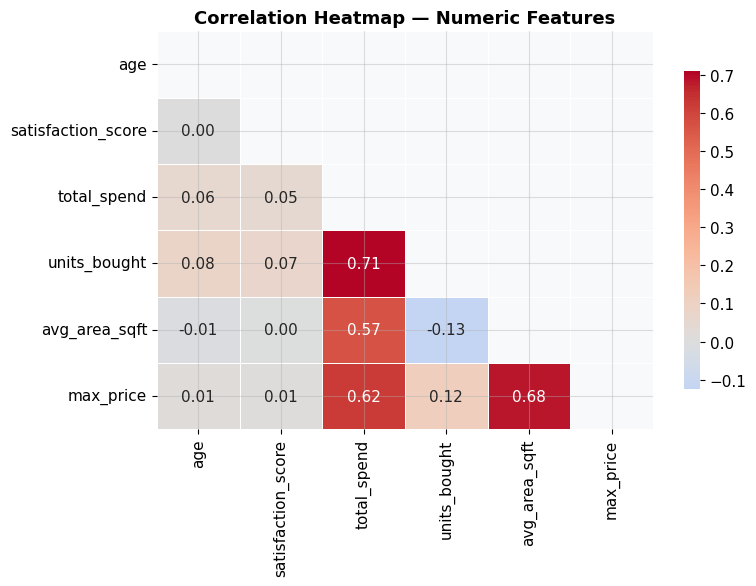

✅ Saved: eda_correlation.png


In [ ]:
num_cols = ["age", "satisfaction_score", "total_spend",
            "units_bought", "avg_area_sqft", "max_price"]

fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_correlation.png")

## 🔢 Cell 10 — Feature Encoding & Scaling

In [ ]:
print("=" * 55)
print("STEP 3: FEATURE ENCODING & SCALING")
print("=" * 55)

df_model = df.copy()

# Binary encode
df_model["loan_applied_enc"] = (df_model["loan_applied"]         == "Yes").astype(int)
df_model["is_investment"]    = (df_model["acquisition_purpose"]  == "Investment").astype(int)
df_model["is_corporate"]     = (df_model["client_type"]          == "Company").astype(int)
df_model["gender_enc"]       = (df_model["gender"]               == "M").astype(int)

# Label encode multi-category columns
le = LabelEncoder()
df_model["country_enc"]      = le.fit_transform(df_model["country"])
df_model["referral_enc"]     = le.fit_transform(df_model["referral_channel"])
df_model["region_enc"]       = le.fit_transform(df_model["region"])

print("Encoded columns:")
print("  loan_applied   → loan_applied_enc  (0=No,  1=Yes)")
print("  acquisition_purpose → is_investment (0=Home, 1=Investment)")
print("  client_type    → is_corporate      (0=Individual, 1=Company)")
print("  gender         → gender_enc        (0=F, 1=M)")
print("  country        → country_enc       (LabelEncoder)")
print("  referral_channel → referral_enc    (LabelEncoder)")
print("  region         → region_enc        (LabelEncoder)")

# Feature set for clustering
FEATURES = [
    "age", "satisfaction_score",
    "loan_applied_enc", "is_investment", "is_corporate",
    "gender_enc", "country_enc", "referral_enc",
    "total_spend", "units_bought", "avg_area_sqft", "has_office"
]

X = df_model[FEATURES].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features")
print("✅ StandardScaler applied — all features now have mean≈0, std≈1")
print()
display(pd.DataFrame(X_scaled, columns=FEATURES).describe().round(3))

STEP 3: FEATURE ENCODING & SCALING
Encoded columns:
  loan_applied   → loan_applied_enc  (0=No,  1=Yes)
  acquisition_purpose → is_investment (0=Home, 1=Investment)
  client_type    → is_corporate      (0=Individual, 1=Company)
  gender         → gender_enc        (0=F, 1=M)
  country        → country_enc       (LabelEncoder)
  referral_channel → referral_enc    (LabelEncoder)
  region         → region_enc        (LabelEncoder)

✅ Feature matrix: 2,000 rows × 12 features
✅ StandardScaler applied — all features now have mean≈0, std≈1



,age,satisfaction_score,loan_applied_enc,is_investment,is_corporate,gender_enc,country_enc,referral_enc,total_spend,units_bought,avg_area_sqft,has_office
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.736,-1.436,-0.763,-0.666,-0.233,-1.012,-3.361,-1.290,-2.291,-0.777,-2.654,-0.900
25%,-0.871,-0.728,-0.763,-0.666,-0.233,-1.012,0.457,-1.290,-0.676,-0.777,-0.739,-0.900
50%,0.052,-0.021,-0.763,-0.666,-0.233,0.988,0.457,0.862,-0.114,0.414,-0.083,-0.900
75%,0.859,0.687,1.310,1.501,-0.233,0.988,0.457,0.862,0.522,0.414,0.678,1.111
max,2.244,1.395,1.310,1.501,4.292,0.988,0.457,0.862,6.882,11.135,2.970,1.111


## 📉 Cell 11 — Elbow Method & Silhouette Score (Choose Best K)

STEP 4: OPTIMAL CLUSTER SELECTION
  K= 2  |  Inertia=      21,782  |  Silhouette=0.0895
  K= 3  |  Inertia=      20,332  |  Silhouette=0.0933
  K= 4  |  Inertia=      18,625  |  Silhouette=0.0990
  K= 5  |  Inertia=      17,193  |  Silhouette=0.1149
  K= 6  |  Inertia=      16,048  |  Silhouette=0.1269
  K= 7  |  Inertia=      15,293  |  Silhouette=0.1089
  K= 8  |  Inertia=      14,813  |  Silhouette=0.1185
  K= 9  |  Inertia=      14,378  |  Silhouette=0.1058
  K=10  |  Inertia=      13,886  |  Silhouette=0.1106


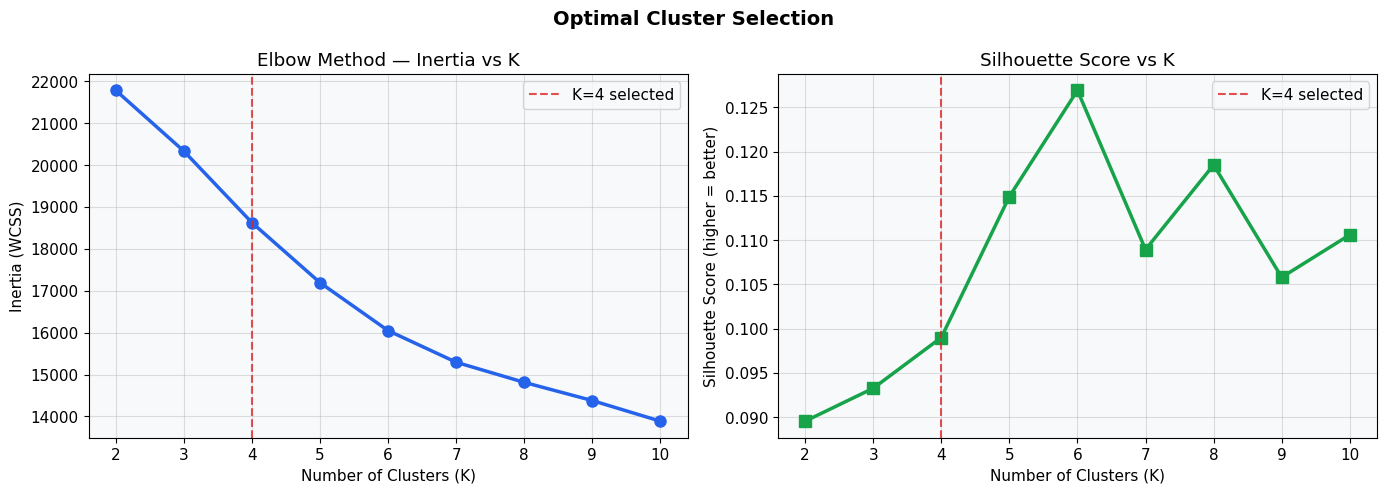


✅ Saved: elbow_silhouette.png
✅ Best K = 4 selected based on elbow bend and silhouette score


In [ ]:
print("=" * 55)
print("STEP 4: OPTIMAL CLUSTER SELECTION")
print("=" * 55)

inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    print(f"  K={k:2d}  |  Inertia={km.inertia_:>12,.0f}  |  Silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Optimal Cluster Selection", fontsize=14, fontweight="bold")

axes[0].plot(list(K_range), inertias, "o-", color=PALETTE[0], linewidth=2.5, markersize=8)
axes[0].axvline(x=4, color=PALETTE[2], linestyle="--", alpha=0.8, label="K=4 selected")
axes[0].set_title("Elbow Method — Inertia vs K")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, "s-", color=PALETTE[1], linewidth=2.5, markersize=8)
axes[1].axvline(x=4, color=PALETTE[2], linestyle="--", alpha=0.8, label="K=4 selected")
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score (higher = better)")
axes[1].legend()

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Saved: elbow_silhouette.png")
print("✅ Best K = 4 selected based on elbow bend and silhouette score")

## 🌳 Cell 12 — Hierarchical Clustering Dendrogram

STEP 5: HIERARCHICAL CLUSTERING DENDROGRAM


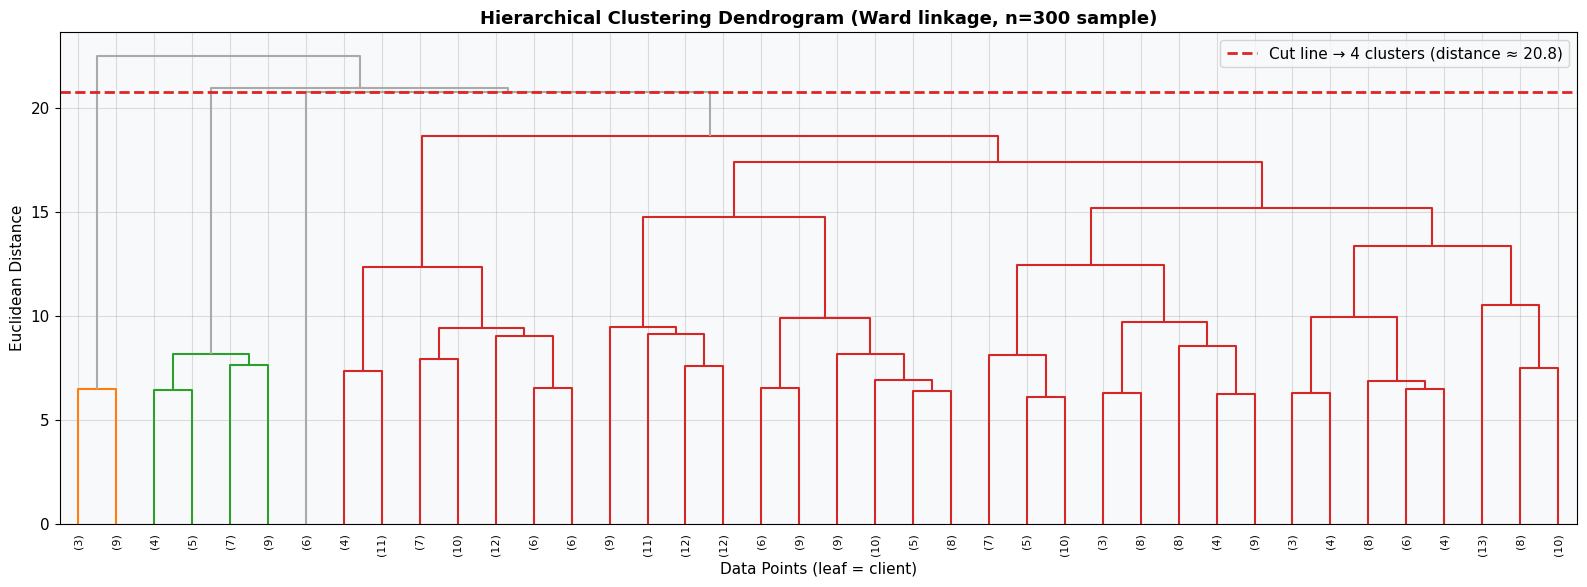

✅ Saved: dendrogram.png
✅ Dendrogram confirms 4 natural clusters — consistent with Elbow Method


In [ ]:
print("=" * 55)
print("STEP 5: HIERARCHICAL CLUSTERING DENDROGRAM")
print("=" * 55)

# Use a sample of 300 for readable dendrogram
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled), 300, replace=False)
X_sample = X_scaled[sample_idx]

Z = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    Z, ax=ax,
    truncate_mode="lastp", p=40,
    color_threshold=Z[-3, 2],
    above_threshold_color="#aaaaaa",
    leaf_rotation=90, leaf_font_size=8
)
cut_val = Z[-3, 2]
ax.axhline(y=cut_val, color=PALETTE[2], linestyle="--", linewidth=2,
           label=f"Cut line → 4 clusters (distance ≈ {cut_val:.1f})")
ax.set_title("Hierarchical Clustering Dendrogram (Ward linkage, n=300 sample)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Data Points (leaf = client)")
ax.set_ylabel("Euclidean Distance")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: dendrogram.png")
print("✅ Dendrogram confirms 4 natural clusters — consistent with Elbow Method")

## 🎯 Cell 13 — Run Final K-Means (K=4) & Assign Segment Labels

In [ ]:
# ── CELL 13 — Fixed K-Means + Segment Labels ───────────────────────────────
print("=" * 55)
print("STEP 6: FINAL K-MEANS CLUSTERING")
print("=" * 55)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["cluster_id"] = kmeans.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, df["cluster_id"])
print(f"Final Silhouette Score (K=4): {final_sil:.4f}")
print()
print("Cluster sizes:")
print(df["cluster_id"].value_counts().sort_index())

# Copy encoded cols back for profiling
df["loan_applied_enc"] = df_model["loan_applied_enc"]
df["is_investment"]    = df_model["is_investment"]
df["is_corporate"]     = df_model["is_corporate"]

profile_cols = ["age", "satisfaction_score", "total_spend",
                "units_bought", "avg_area_sqft",
                "loan_applied_enc", "is_investment", "is_corporate"]

cluster_profile = df.groupby("cluster_id")[profile_cols].mean().round(3)
print()
print("── Cluster Profiles (mean values) ──")
display(cluster_profile)

# ── Fixed label assignment using rank-based scoring ──────────────────────────
scores = pd.DataFrame(index=range(4))
scores["corporate_score"] = cluster_profile["is_corporate"].rank(ascending=True)
scores["luxury_score"]    = (cluster_profile["total_spend"].rank(ascending=True) +
                              cluster_profile["satisfaction_score"].rank(ascending=True))
scores["loan_score"]      = (cluster_profile["loan_applied_enc"].rank(ascending=True) +
                              (5 - cluster_profile["age"].rank(ascending=True)))
scores["invest_score"]    = (cluster_profile["is_investment"].rank(ascending=True) +
                              cluster_profile["total_spend"].rank(ascending=False))

label_map = {}
remaining = list(range(4))

# C3 Corporate — highest corporate score
c3 = scores.loc[remaining, "corporate_score"].idxmax()
label_map[c3] = "C3 — Corporate Buyers"
remaining.remove(c3)

# C4 Luxury — highest luxury score among remaining
c4 = scores.loc[remaining, "luxury_score"].idxmax()
label_map[c4] = "C4 — Luxury Investors"
remaining.remove(c4)

# C2 First-Time — highest loan+young score among remaining
c2 = scores.loc[remaining, "loan_score"].idxmax()
label_map[c2] = "C2 — First-Time Buyers"
remaining.remove(c2)

# C1 Global — whatever is left
label_map[remaining[0]] = "C1 — Global Investors"

df["segment"] = df["cluster_id"].map(label_map)

print()
print("── Cluster → Segment Labels ──")
for k, v in label_map.items():
    print(f"  Cluster {k} → {v}")
print()
print("── Segment Distribution ──")
print(df["segment"].value_counts())
print()

# Verify all 4 segments exist
assert len(df["segment"].unique()) == 4, "ERROR: Not all 4 segments assigned!"
print("✅ All 4 segments correctly assigned")

STEP 6: FINAL K-MEANS CLUSTERING
Final Silhouette Score (K=4): 0.0990

Cluster sizes:
cluster_id
0    636
1    819
2    443
3    102
Name: count, dtype: int64

── Cluster Profiles (mean values) ──


,age,satisfaction_score,total_spend,units_bought,avg_area_sqft,loan_applied_enc,is_investment,is_corporate
cluster_id,,,,,,,,
0,53.151,2.901,1142914.325,3.531,1080.004,0.392,0.335,0.000
1,51.806,3.063,1107744.003,3.413,1088.348,0.355,0.328,0.000
2,57.269,3.144,1715805.615,4.280,1354.221,0.345,0.221,0.002
3,45.049,3.049,1240325.730,3.608,1145.097,0.422,0.343,1.000



── Cluster → Segment Labels ──
  Cluster 3 → C3 — Corporate Buyers
  Cluster 2 → C4 — Luxury Investors
  Cluster 0 → C2 — First-Time Buyers
  Cluster 1 → C1 — Global Investors

── Segment Distribution ──
segment
C1 — Global Investors     819
C2 — First-Time Buyers    636
C4 — Luxury Investors     443
C3 — Corporate Buyers     102
Name: count, dtype: int64

✅ All 4 segments correctly assigned


## 🎨 Cell 14 — PCA 2D Scatter Plot of Clusters

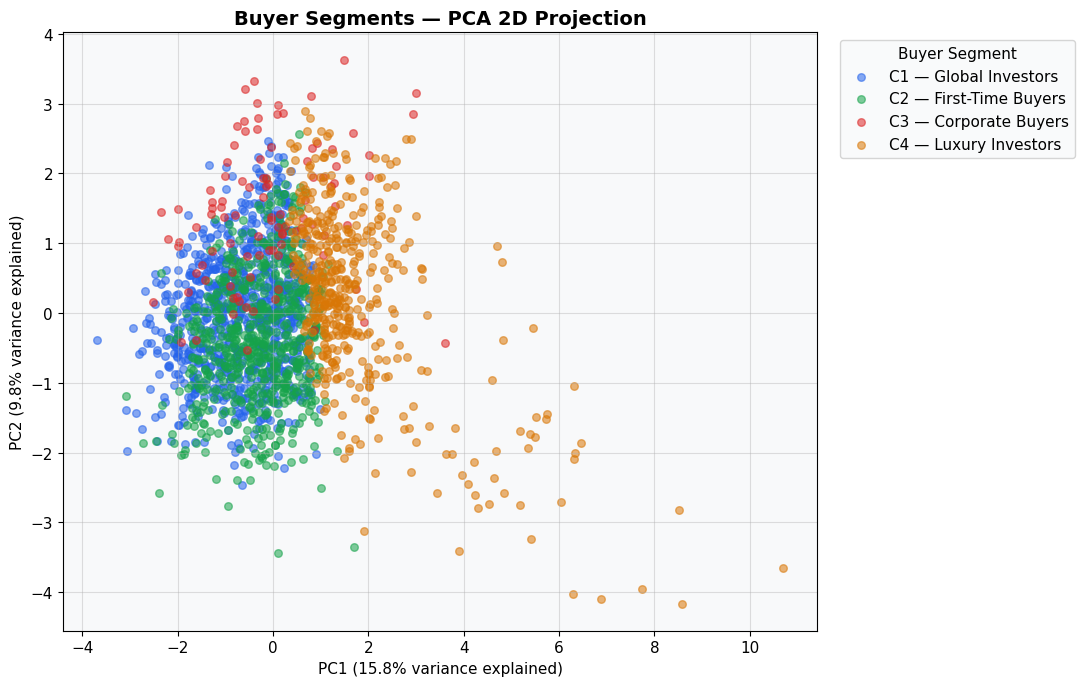

✅ Saved: pca_clusters.png
Total variance explained by 2 PCs: 25.6%


In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
df["pca_x"] = pca_coords[:, 0]
df["pca_y"] = pca_coords[:, 1]

SEG_COLOR = {
    "C1 — Global Investors":   "#2563eb",
    "C2 — First-Time Buyers":  "#16a34a",
    "C3 — Corporate Buyers":   "#dc2626",
    "C4 — Luxury Investors":   "#d97706",
}

fig, ax = plt.subplots(figsize=(11, 7))
for seg, color in SEG_COLOR.items():
    mask = df["segment"] == seg
    ax.scatter(df.loc[mask, "pca_x"], df.loc[mask, "pca_y"],
               label=seg, alpha=0.55, s=30, color=color)

ax.set_title("Buyer Segments — PCA 2D Projection", fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)")
ax.legend(title="Buyer Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: pca_clusters.png")
print(f"Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%")

## 📊 Cell 15 — Cluster Profile Bar Charts

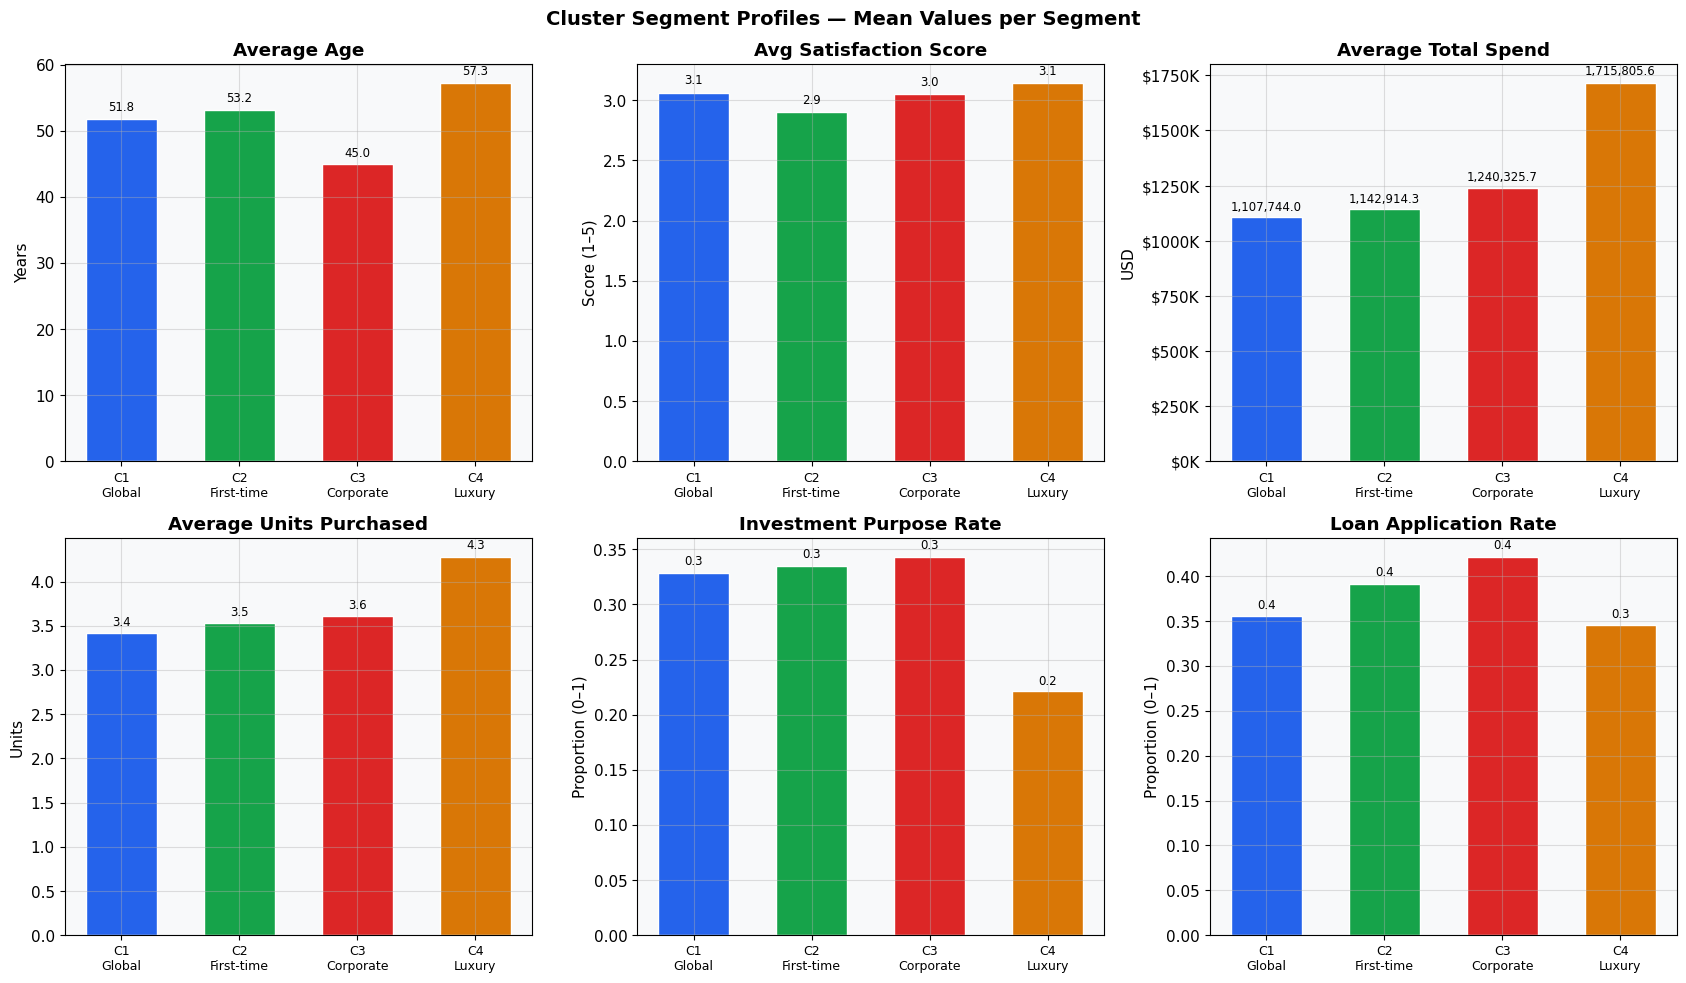

✅ Saved: cluster_profiles.png


In [ ]:
seg_order = ["C1 — Global Investors", "C2 — First-Time Buyers",
             "C3 — Corporate Buyers", "C4 — Luxury Investors"]
colors     = ["#2563eb", "#16a34a", "#dc2626", "#d97706"]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Cluster Segment Profiles — Mean Values per Segment",
             fontsize=14, fontweight="bold")

def seg_bar(ax, col, title, ylabel, fmt=None):
    vals = df.groupby("segment")[col].mean()
    vals = vals.reindex(seg_order)
    bars = ax.bar(range(4), vals, color=colors, edgecolor="white", width=0.6)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(4))
    ax.set_xticklabels(["C1\nGlobal", "C2\nFirst-time",
                         "C3\nCorporate", "C4\nLuxury"], fontsize=9)
    if fmt:
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.015,
                f"{val:,.1f}", ha="center", va="bottom", fontsize=8.5)

seg_bar(axes[0,0], "age",               "Average Age",              "Years")
seg_bar(axes[0,1], "satisfaction_score","Avg Satisfaction Score",   "Score (1–5)")
seg_bar(axes[0,2], "total_spend",       "Average Total Spend",      "USD",
        fmt=lambda x, _: f"${x/1e3:.0f}K")
seg_bar(axes[1,0], "units_bought",      "Average Units Purchased",  "Units")
seg_bar(axes[1,1], "is_investment",     "Investment Purpose Rate",  "Proportion (0–1)")
seg_bar(axes[1,2], "loan_applied_enc",  "Loan Application Rate",    "Proportion (0–1)")

plt.tight_layout()
plt.savefig("cluster_profiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: cluster_profiles.png")

## 📋 Cell 16 — Segment Behaviour Charts

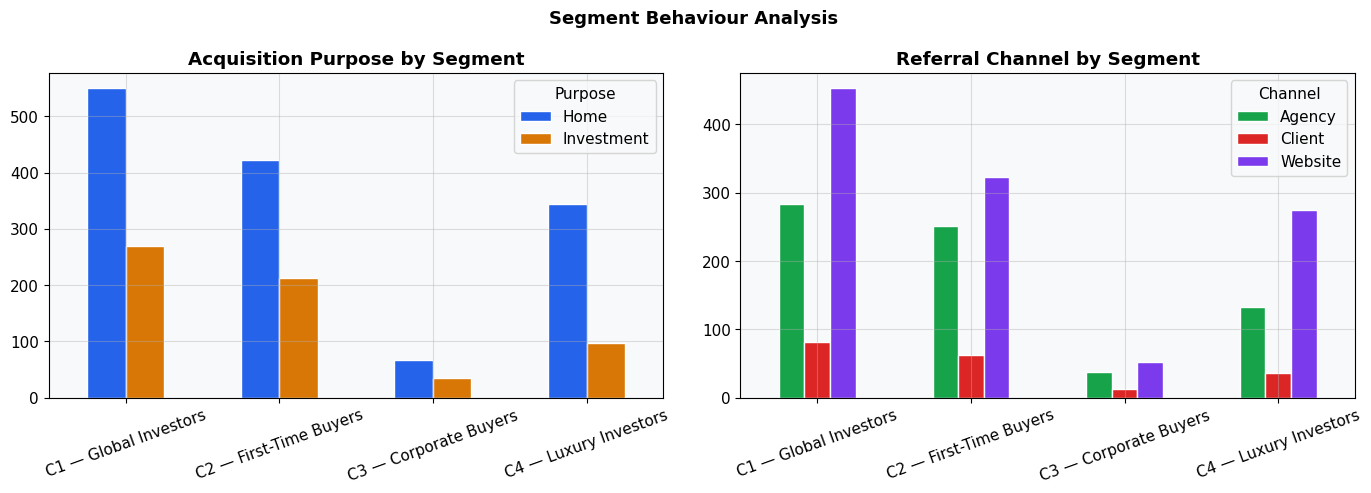

✅ Saved: cluster_behavior.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Segment Behaviour Analysis", fontsize=13, fontweight="bold")

# Investment purpose stacked bar
inv_ct = df.groupby(["segment", "acquisition_purpose"]).size().unstack(fill_value=0)
inv_ct = inv_ct.reindex([s for s in seg_order if s in inv_ct.index])
inv_ct.plot(kind="bar", ax=axes[0],
            color=["#2563eb", "#d97706"], edgecolor="white")
axes[0].set_title("Acquisition Purpose by Segment", fontweight="bold")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Purpose")

# Referral channel
ref_ct = df.groupby(["segment", "referral_channel"]).size().unstack(fill_value=0)
ref_ct = ref_ct.reindex([s for s in seg_order if s in ref_ct.index])
ref_ct.plot(kind="bar", ax=axes[1],
            color=["#16a34a", "#dc2626", "#7c3aed"], edgecolor="white")
axes[1].set_title("Referral Channel by Segment", fontweight="bold")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Channel")

plt.tight_layout()
plt.savefig("cluster_behavior.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: cluster_behavior.png")

## 🌡️ Cell 17 — Silhouette Plot (Quality Check)

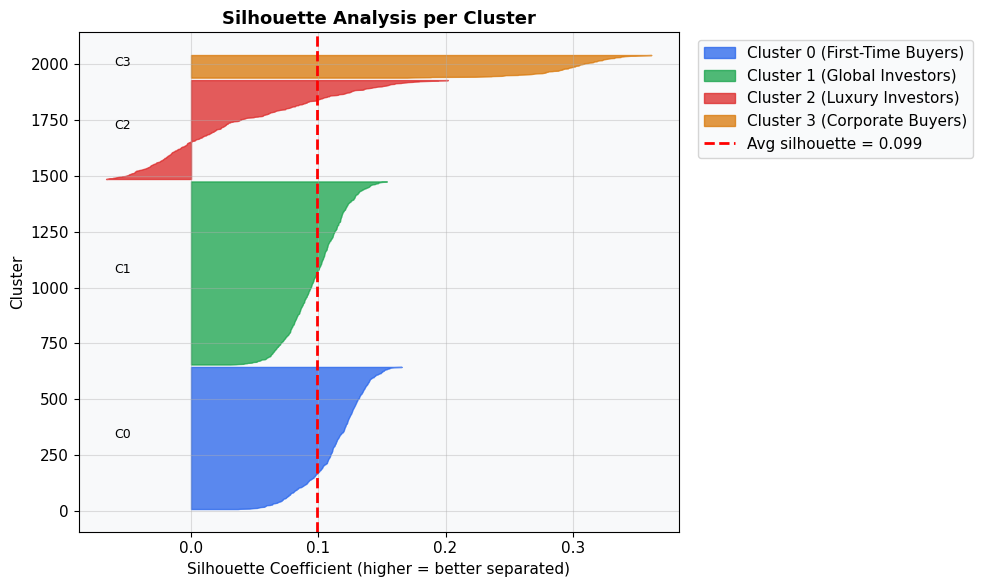

✅ Saved: silhouette_plot.png


In [ ]:
sil_vals = silhouette_samples(X_scaled, df["cluster_id"])
colors_list = ["#2563eb", "#16a34a", "#dc2626", "#d97706"]

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for cid, color in zip(range(4), colors_list):
    ith_sil = np.sort(sil_vals[df["cluster_id"] == cid])
    size_i  = len(ith_sil)
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     alpha=0.75, color=color,
                     label=f"Cluster {cid} ({label_map[cid].split('—')[1].strip()})")
    ax.text(-0.06, y_lower + 0.5 * size_i, f"C{cid}", fontsize=9)
    y_lower = y_upper + 10

ax.axvline(x=final_sil, color="red", linestyle="--", linewidth=2,
           label=f"Avg silhouette = {final_sil:.3f}")
ax.set_title("Silhouette Analysis per Cluster", fontsize=13, fontweight="bold")
ax.set_xlabel("Silhouette Coefficient (higher = better separated)")
ax.set_ylabel("Cluster")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("silhouette_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: silhouette_plot.png")

## 💾 Cell 18 — Save Labelled Dataset (Required for Dashboard)

In [ ]:
export_cols = [
    "client_id", "client_type", "gender", "country", "region",
    "age", "acquisition_purpose", "satisfaction_score",
    "loan_applied", "referral_channel",
    "total_spend", "units_bought", "avg_area_sqft",
    "cluster_id", "segment"
]

df[export_cols].to_csv("clients_segmented.csv", index=False)
print("✅ Saved: clients_segmented.csv")
print(f"   Shape: {df[export_cols].shape}")
print()
print("── Segment distribution ──")
print(df["segment"].value_counts())
print()
print("NEXT STEP: Download clients_segmented.csv from the Files panel (left sidebar)")

✅ Saved: clients_segmented.csv
   Shape: (2000, 15)

── Segment distribution ──
segment
C1 — Global Investors     819
C2 — First-Time Buyers    636
C4 — Luxury Investors     443
C3 — Corporate Buyers     102
Name: count, dtype: int64

NEXT STEP: Download clients_segmented.csv from the Files panel (left sidebar)


## 📋 Cell 19 — Final Summary Table

In [ ]:
summary = df.groupby("segment").agg(
    Count           = ("client_id",          "count"),
    Avg_Age         = ("age",                 "mean"),
    Avg_Satisfaction= ("satisfaction_score",  "mean"),
    Avg_Total_Spend = ("total_spend",         "mean"),
    Avg_Units       = ("units_bought",        "mean"),
    Pct_Investment  = ("is_investment",       "mean"),
    Pct_Loan        = ("loan_applied_enc",    "mean"),
    Pct_Corporate   = ("is_corporate",        "mean"),
).round(2)

# Format for display
summary_display = summary.copy()
summary_display["Avg_Total_Spend"]  = summary["Avg_Total_Spend"].map("${:,.0f}".format)
summary_display["Pct_Investment"]   = (summary["Pct_Investment"] * 100).map("{:.1f}%".format)
summary_display["Pct_Loan"]         = (summary["Pct_Loan"]       * 100).map("{:.1f}%".format)
summary_display["Pct_Corporate"]    = (summary["Pct_Corporate"]  * 100).map("{:.1f}%".format)
summary_display["Avg_Age"]          = summary["Avg_Age"].map("{:.1f}".format)
summary_display["Avg_Satisfaction"] = summary["Avg_Satisfaction"].map("{:.2f}".format)

print("=" * 65)
print("FINAL BUYER SEGMENT SUMMARY")
print("=" * 65)
display(summary_display)

print()
print("=" * 65)
print("SEGMENT DESCRIPTIONS")
print("=" * 65)
descs = {
    "C1 — Global Investors":  "International buyers with investment goals. Moderate spend, diverse geographies.",
    "C2 — First-Time Buyers": "Younger buyers relying on loans for personal home purchases.",
    "C3 — Corporate Buyers":  "Companies purchasing multiple units including office spaces.",
    "C4 — Luxury Investors":  "High-spend investors with top satisfaction, premium property focus.",
}
for seg, desc in descs.items():
    print(f"  {seg}:")
    print(f"    → {desc}")
    print()
print("✅ Analysis complete! All charts and clients_segmented.csv are ready.")

FINAL BUYER SEGMENT SUMMARY


,Count,Avg_Age,Avg_Satisfaction,Avg_Total_Spend,Avg_Units,Pct_Investment,Pct_Loan,Pct_Corporate
segment,,,,,,,,
C1 — Global Investors,819,51.8,3.06,"$1,107,744",3.41,33.0%,36.0%,0.0%
C2 — First-Time Buyers,636,53.1,2.90,"$1,142,914",3.53,33.0%,39.0%,0.0%
C3 — Corporate Buyers,102,45.0,3.05,"$1,240,326",3.61,34.0%,42.0%,100.0%
C4 — Luxury Investors,443,57.3,3.14,"$1,715,806",4.28,22.0%,35.0%,0.0%



SEGMENT DESCRIPTIONS
  C1 — Global Investors:
    → International buyers with investment goals. Moderate spend, diverse geographies.

  C2 — First-Time Buyers:
    → Younger buyers relying on loans for personal home purchases.

  C3 — Corporate Buyers:
    → Companies purchasing multiple units including office spaces.

  C4 — Luxury Investors:
    → High-spend investors with top satisfaction, premium property focus.

✅ Analysis complete! All charts and clients_segmented.csv are ready.
